In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## SSD WITH MOMENTUM

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.layers import Dense , Dropout
from keras.optimizers import SGD
from keras.models import Sequential
# 1. Load and preprocess data
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 28*28).astype("float32") / 255.0
x_test  = x_test.reshape(-1, 28*28).astype("float32") / 255.0

# create archituter 


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(10, activation="softmax")
])
# initialize optimizer
optimizer = SGD(
    learning_rate = 0.01,
    momentum = 0.9,
    nesterov=True  
)

# compile the model
model.compile(loss="sparse_categorical_crossentropy",
              optimizer = optimizer,
              metrics = ["accuracy"]
             )
# 4. Train
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)





2026-03-14 03:11:57.896258: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773457918.119937      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773457918.182388      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773457918.688182      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773457918.688253      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773457918.688256      17 computation_placer.cc:177] computation placer alr

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-14 03:12:27.070025: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6566 - loss: 1.0717 - val_accuracy: 0.9395 - val_loss: 0.2111
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9031 - loss: 0.3253 - val_accuracy: 0.9548 - val_loss: 0.1542
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9273 - loss: 0.2473 - val_accuracy: 0.9628 - val_loss: 0.1299
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9398 - loss: 0.2037 - val_accuracy: 0.9683 - val_loss: 0.1111
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9447 - loss: 0.1852 - val_accuracy: 0.9708 - val_loss: 0.1014
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9530 - loss: 0.1569 - val_accuracy: 0.9728 - val_loss: 0.0956
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9576 - loss: 0.1448 - val_accuracy: 0.9747 - val_loss: 0.0867
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9587 - loss: 0.1330 - val_accuracy: 0.

test_accuracy = 0.9743000268936157 


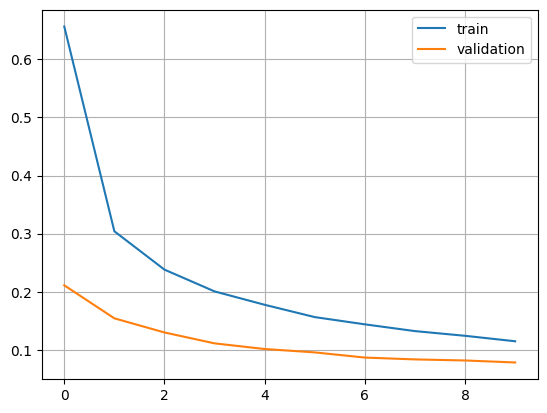

In [3]:
# Evaluate 
import matplotlib.pyplot as plt
test_loss , test_accuracy = model.evaluate(x_test,y_test,verbose=0)
print(f"test_accuracy = {test_accuracy} ")
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(['train','validation'])
plt.grid()
plt.show()

## Adagrad optimizer

In [4]:
from keras.optimizers import Adagrad
optimizer = Adagrad(learning_rate=0.01)
model.compile(optimizer = optimizer,
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"]
             )

# fit the model 
history=model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size = 32,
    validation_split = 0.1,
    verbose = 1
    
)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9679 - loss: 0.1057 - val_accuracy: 0.9765 - val_loss: 0.0764
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9684 - loss: 0.1022 - val_accuracy: 0.9778 - val_loss: 0.0732
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9715 - loss: 0.0927 - val_accuracy: 0.9782 - val_loss: 0.0715
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9722 - loss: 0.0897 - val_accuracy: 0.9797 - val_loss: 0.0711
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9743 - loss: 0.0835 - val_accuracy: 0.9800 - val_loss: 0.0693
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9746 - loss: 0.0827 - val_accuracy: 0.9805 - val_loss: 0.0700
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9751 - loss: 0.0793 - val_accuracy: 0.9810 - val_loss: 0.0677
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9760 - loss: 0.0771 - 

In [5]:
# evalute the result
test_loss , test_acc = model.evaluate(x_test,y_test,verbose=0)
print(f"test accuracy is : {test_acc}")


test accuracy is : 0.9805999994277954


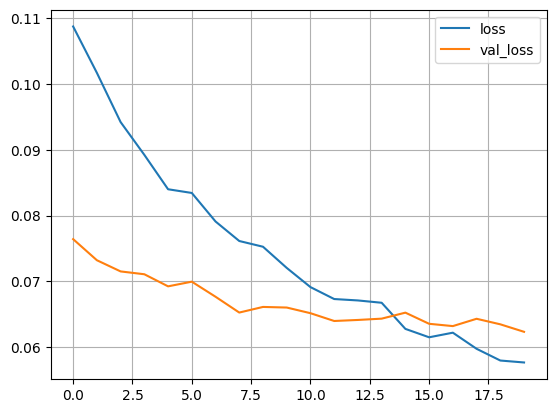

In [6]:
# visulize the model
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["loss","val_loss"])
plt.grid()
plt.show()

## RMSprop optimizer

In [7]:
from keras.optimizers import RMSprop
RMS_optimizer = RMSprop(
    learning_rate = 0.001,
    rho=0.9,
    epsilon = 1e-7
)

In [8]:
model.compile(optimizer = RMS_optimizer,
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"]
             )

# fit the model 
history=model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size = 32,
    validation_split = 0.1,
    verbose = 1
    
)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9676 - loss: 0.0979 - val_accuracy: 0.9733 - val_loss: 0.0957
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9717 - loss: 0.0959 - val_accuracy: 0.9787 - val_loss: 0.0917
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9738 - loss: 0.0935 - val_accuracy: 0.9792 - val_loss: 0.0855
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9726 - loss: 0.0957 - val_accuracy: 0.9815 - val_loss: 0.0808
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9748 - loss: 0.0905 - val_accuracy: 0.9810 - val_loss: 0.0858
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9767 - loss: 0.0831 - val_accuracy: 0.9822 - val_loss: 0.0869
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9769 - loss: 0.0836 - val_accuracy: 0.9802 - val_loss: 0.0954
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9791 - loss: 0.0773 - 

In [9]:
# evalute the result
test_loss , test_acc = model.evaluate(x_test,y_test,verbose=0)
print(f"test accuracy is : {test_acc}")


test accuracy is : 0.978600025177002


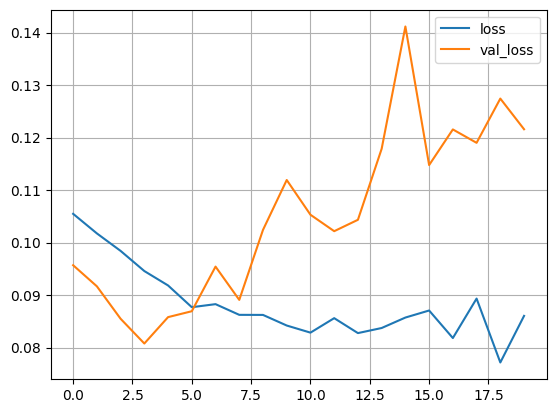

In [10]:
# visulize the model
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["loss","val_loss"])
plt.grid()
plt.show()

# Adam optimizer

In [11]:
from keras.optimizers import Adam
model.compile(optimizer = "Adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"]
             )

# fit the model 
history=model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size = 32,
    validation_split = 0.1,
    verbose = 1
    
)
# fit the model 
history=model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size = 32,
    validation_split = 0.1,
    verbose = 1
    
)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9768 - loss: 0.1010 - val_accuracy: 0.9758 - val_loss: 0.1181
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9792 - loss: 0.0804 - val_accuracy: 0.9803 - val_loss: 0.1014
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9797 - loss: 0.0720 - val_accuracy: 0.9797 - val_loss: 0.0959
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9793 - loss: 0.0706 - val_accuracy: 0.9813 - val_loss: 0.0930
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9805 - loss: 0.0678 - val_accuracy: 0.9793 - val_loss: 0.0811
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9804 - loss: 0.0629 - val_accuracy: 0.9805 - val_loss: 0.0917
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9822 - loss: 0.0568 - val_accuracy: 0.9822 - val_loss: 0.0873
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9834 - loss: 0.0549 - 

In [12]:
# evalute the result
test_loss , test_acc = model.evaluate(x_test,y_test,verbose=0)
print(f"test accuracy is : {test_acc}")


test accuracy is : 0.9829999804496765


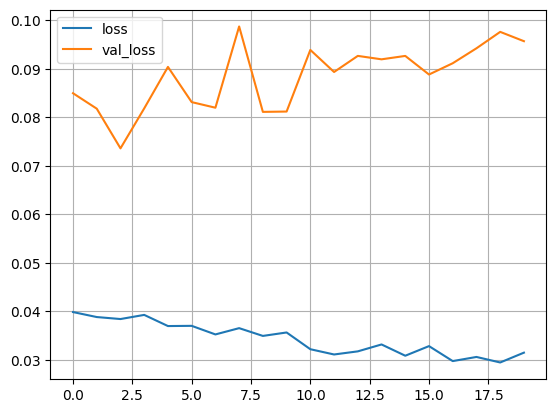

In [13]:
# visulize the model
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["loss","val_loss"])
plt.grid()
plt.show()